# AI Challenge 2 Notebook

#### written by Max DeJesus

This notebook looks into text-to-audio based generation using the MusicGen Small model within HuggingFace. I explore what the model can produce and perform modulations to improve results and compare evaluations between differing parameters.

In [23]:
!nvidia-smi

Tue Apr 28 04:44:30 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   64C    P0             32W /   72W |    3530MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [24]:
import os
import numpy as np
import torch
from transformers import pipeline, AutoProcessor, ClapModel, MusicgenForConditionalGeneration, AutoModel, AutoTokenizer
import scipy
import torch.nn.functional as F
import torchaudio.transforms as T
import random
import time
import functools

## Initialization of tools

Here the model and various tools are initialzed for use throughout the notebook, including the MusicGen Small model and prompt processor, as well as the CLAP model.

The CLAP model evaluates the generated output by evaluating its likeliness to the original prompt. It's implementation is similar to the CLIP models used for image evaluation. A score of 1 indicates an exact match to the prompt, and a score of 0 being entirely unrelated to the prompt (at least according to the model).

In [25]:
# Create and load music generation model and generator

model = MusicgenForConditionalGeneration.from_pretrained("facebook/musicgen-small")
processor = AutoProcessor.from_pretrained("facebook/musicgen-small")
device = "cuda:0" if torch.cuda.is_available() else "cpu"
m = model.to(device)

Loading weights:   0%|          | 0/611 [00:00<?, ?it/s]

MusicgenForConditionalGeneration LOAD REPORT from: facebook/musicgen-small
Key                                           | Status     |  | 
----------------------------------------------+------------+--+-
decoder.model.decoder.embed_positions.weights | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [26]:
# Evaluation model and processor init
eval_model = ClapModel.from_pretrained("laion/clap-htsat-unfused").to(device)
eval_processor = AutoProcessor.from_pretrained("laion/clap-htsat-unfused")

Loading weights:   0%|          | 0/447 [00:00<?, ?it/s]

In [27]:
# Boilerplate to set seeds quickly
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [28]:
# Time function execution
def timer(func):
    """Decorator that prints the execution time of the function it wraps."""
    @functools.wraps(func)
    def wrapper(*args, **kwargs):
        start_time = time.perf_counter()
        result = func(*args, **kwargs)
        end_time = time.perf_counter()

        duration = end_time - start_time
        print(f"Executed {func.__name__!r} in {duration:.4f} seconds")
        return result
    return wrapper

## Main functions

These functions host the boilerplate code for audio generation and evaluation.

In [29]:
# Generate a tune with MusicGen Small
@timer
def generate_tune(prompt, filename, guidance_scale=3, temperature=1, save=True):
  # Process user prompt
  inputs = processor(
      text=[prompt],
      padding=True,
      return_tensors="pt"
  )

  # Generate audio and save to file
  audio_values = model.generate(**inputs.to(device),
                                do_sample=True,
                                guidance_scale=guidance_scale,
                                temperature=temperature,
                                max_new_tokens=256)
  sampling_rate = model.config.audio_encoder.sampling_rate

  if save:
    scipy.io.wavfile.write(f"{filename}.wav", rate=sampling_rate, data=audio_values[0, 0].cpu().numpy())
  return audio_values

In [30]:
# Evaluate CLAP score for generated audio
def evaluate_clap(audio_values, prompt):
  # Convert audio to 48k sample rate
  audio_tensor = audio_values.squeeze(0).cpu()
  resampler = T.Resample(orig_freq=32000, new_freq=48000)
  audio_48k = resampler(audio_tensor)

  # Create eval input and calculate score
  eval_input = eval_processor(
      text=[prompt],
      audio=audio_48k.numpy(),
      sampling_rate=48000,
      return_tensors="pt",
      padding=True
  ).to(device)

  with torch.no_grad():
    outputs = eval_model(**eval_input)
    score = F.cosine_similarity(outputs.text_embeds, outputs.audio_embeds)
  return score.item()

## Unprompted Generation

This is the model creating a tune with no user intervention, entirely original! /s

All generated output will use the same number of samples, resulting in about five seconds of audio per clip.

In [31]:
# Generate a tune (without prompting)
unconditional_inputs = model.get_unconditional_inputs(num_samples=1)
audio_values = model.generate(**unconditional_inputs, do_sample=True, max_new_tokens=256)
sampling_rate = model.config.audio_encoder.sampling_rate

audio_length_in_s = 256 / model.config.audio_encoder.frame_rate
print(f'Length of track (s): {audio_length_in_s}')

# Save audios to file
scipy.io.wavfile.write("musicgen_out_uncond.wav", rate=sampling_rate, data=audio_values[0, 0].cpu().numpy())

Length of track (s): 5.12


## Prompted Generation

Here let's create a jazz tune using the MusicGen Small model.

### Simple

In [32]:
# Set seed for reproducibility
set_seed(3852)

prompt = "Jazz music"

audio_values = generate_tune(prompt, 'musicgen_simple_ex1')

score = evaluate_clap(audio_values, prompt)
print(f"CLAP Score: {score:.4f}")

Executed 'generate_tune' in 6.1186 seconds
CLAP Score: 0.1145


### Complex

In [33]:
set_seed(3852)

prompt = "Jazz music, light drums and piano with thumpy bass lines, high quality"

audio_values = generate_tune(prompt, 'musicgen_complex_ex1')

score = evaluate_clap(audio_values, prompt)
print(f"CLAP Score: {score:.4f}")

Executed 'generate_tune' in 6.0902 seconds
CLAP Score: 0.3432


## Another example

Let's create a pop-rock/punk style song.

### Simple

In [34]:
set_seed(3852)

prompt = "Pop-punk song"

audio_values = generate_tune(prompt, 'musicgen_simple_ex2')

score = evaluate_clap(audio_values, prompt)
print(f"CLAP Score: {score:.4f}")

Executed 'generate_tune' in 6.1183 seconds
CLAP Score: 0.2722


### Complex

In [35]:
set_seed(3852)

prompt = "2000s Pop-punk song, big guitar riffs and fast drum beats, high quality"

audio_values = generate_tune(prompt, 'musicgen_complex_ex2')

score = evaluate_clap(audio_values, prompt)
print(f"CLAP Score: {score:.4f}")

Executed 'generate_tune' in 6.1740 seconds
CLAP Score: 0.5156


## Taking things further

Let's take our last example and experiment with different parameters to see if the CLAP score can go higher.

In [36]:
clap_scores = {}
prompt = "2000s Pop-punk song, big guitar riffs and fast drum beats, high quality"

for cfg in np.arange(3,9,0.4):
  set_seed(3852)
  print(f"Testing with CFG {cfg}")
  audio_values = generate_tune(prompt, '', guidance_scale=cfg, save=False)
  score = evaluate_clap(audio_values, prompt)
  clap_scores[float(cfg)] = score

print(f"CLAP Scores: {clap_scores}")

Testing with CFG 3.0
Executed 'generate_tune' in 6.1834 seconds
Testing with CFG 3.4
Executed 'generate_tune' in 6.3431 seconds
Testing with CFG 3.8
Executed 'generate_tune' in 6.4716 seconds
Testing with CFG 4.199999999999999
Executed 'generate_tune' in 6.3329 seconds
Testing with CFG 4.6
Executed 'generate_tune' in 6.1232 seconds
Testing with CFG 5.0
Executed 'generate_tune' in 6.1652 seconds
Testing with CFG 5.3999999999999995
Executed 'generate_tune' in 6.1250 seconds
Testing with CFG 5.799999999999999
Executed 'generate_tune' in 6.2935 seconds
Testing with CFG 6.199999999999999
Executed 'generate_tune' in 6.1392 seconds
Testing with CFG 6.6
Executed 'generate_tune' in 6.0847 seconds
Testing with CFG 6.999999999999999
Executed 'generate_tune' in 5.9969 seconds
Testing with CFG 7.399999999999999
Executed 'generate_tune' in 6.0756 seconds
Testing with CFG 7.799999999999999
Executed 'generate_tune' in 6.1483 seconds
Testing with CFG 8.2
Executed 'generate_tune' in 6.1060 seconds
Testi

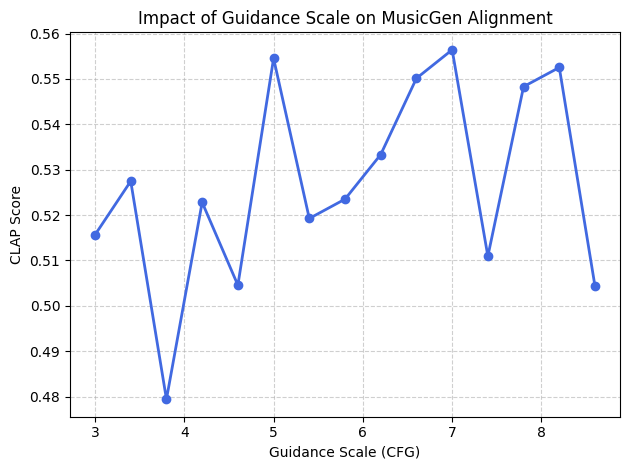

In [37]:
import matplotlib.pyplot as plt

plt.plot(clap_scores.keys(), clap_scores.values(), marker='o', linestyle='-', color='royalblue', linewidth=2)
plt.xlabel('Guidance Scale (CFG)')
plt.ylabel('CLAP Score')
plt.title('Impact of Guidance Scale on MusicGen Alignment')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

In [38]:
# Perform test with varying temperatures (guidance scale 5 as local max)

clap_scores = {}
prompt = "2000s Pop-punk song, big guitar riffs and fast drum beats, high quality"

for t in np.arange(0.1,1.6,0.1):
  set_seed(3852)
  print(f"Testing with temperature {t}")
  audio_values = generate_tune(prompt, '', guidance_scale=5, temperature=t, save=False)
  score = evaluate_clap(audio_values, prompt)
  clap_scores[float(t)] = score

print(f"CLAP Scores: {clap_scores}")

Testing with temperature 0.1
Executed 'generate_tune' in 6.0661 seconds
Testing with temperature 0.2
Executed 'generate_tune' in 6.1504 seconds
Testing with temperature 0.30000000000000004
Executed 'generate_tune' in 6.0874 seconds
Testing with temperature 0.4
Executed 'generate_tune' in 6.0890 seconds
Testing with temperature 0.5
Executed 'generate_tune' in 5.9547 seconds
Testing with temperature 0.6
Executed 'generate_tune' in 6.0899 seconds
Testing with temperature 0.7000000000000001
Executed 'generate_tune' in 6.0970 seconds
Testing with temperature 0.8
Executed 'generate_tune' in 6.1434 seconds
Testing with temperature 0.9
Executed 'generate_tune' in 6.1133 seconds
Testing with temperature 1.0
Executed 'generate_tune' in 6.1040 seconds
Testing with temperature 1.1
Executed 'generate_tune' in 6.0477 seconds
Testing with temperature 1.2000000000000002
Executed 'generate_tune' in 6.1211 seconds
Testing with temperature 1.3000000000000003
Executed 'generate_tune' in 6.1097 seconds
Tes

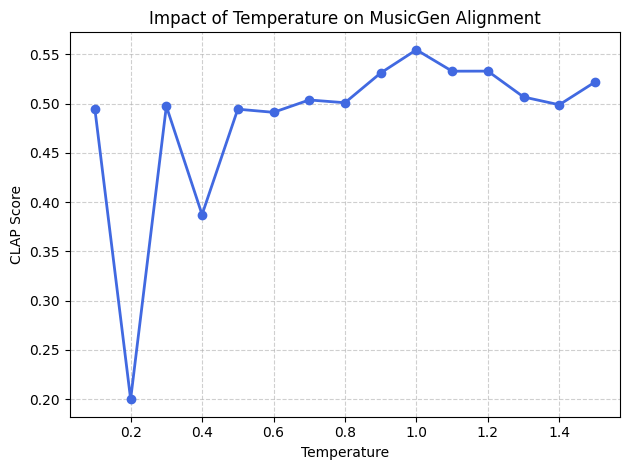

In [43]:
plt.plot(clap_scores.keys(), clap_scores.values(), marker='o', linestyle='-', color='royalblue', linewidth=2)
plt.xlabel('Temperature')
plt.ylabel('CLAP Score')
plt.title('Impact of Temperature on MusicGen Alignment')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

## Conclusion

After determining how the attributes change our outputs, let's use the knowledge to get our original prompts in their "best" form.

In [41]:
set_seed(3852)

prompt = "Jazz music, light drums and piano with thumpy bass lines, high quality"

audio_values = generate_tune(prompt, 'musicgen_ex1_final', guidance_scale=5)

score = evaluate_clap(audio_values, prompt)
print(f"CLAP Score: {score:.4f}")

Executed 'generate_tune' in 6.1435 seconds
CLAP Score: 0.4857


In [42]:
set_seed(3852)

prompt = "2000s Pop-punk song, big guitar riffs and fast drum beats, high quality"

audio_values = generate_tune(prompt, 'musicgen_ex2_final', guidance_scale=5)

score = evaluate_clap(audio_values, prompt)
print(f"CLAP Score: {score:.4f}")

Executed 'generate_tune' in 6.1552 seconds
CLAP Score: 0.5545
